In [1]:
# Globals
import numpy as np

from shared_util.pipelines import ModelPipeline
import warnings
warnings.filterwarnings('ignore')

METRICS_DB_ID = 6
METRICS_NOTES = "binning v3"
PCA = False
scaler = 'standard' # 'standard' for StandardScaler or 'power' for PowerTransformer (yeo-johnson)



UPDATE_DATABASE = False

LOG_TRANSFORM_COLS = np.array(
    ['num_medications', 'num_procedures', 'time_in_hospital'
     ])

# Results

In [2]:
from shared_util.fetch import fetch_metric, fetch_all_metrics
import pandas as pd
from shared_util.pd_util import filter_df

metrics_df = fetch_all_metrics()

pca_ = filter_df(metrics_df, run_id=2)
log_scale_ = filter_df(metrics_df, run_id=1)
pt_ = filter_df(metrics_df, run_id=3)
pt_log = filter_df(metrics_df, run_id=4)
bin_v2 = filter_df(metrics_df, run_id=5)
bin_v3 = filter_df(metrics_df, run_id=6)

# pca_results_df = fetch_metric(run_id=2)
# results_df = fetch_metric(run_id=1)

# pt_df = fetch_metric(run_id=3)

# pt_log_df = fetch_metric(run_id=4)

# new_bin = fetch_metric(run_id=5)

# bin_3 = fetch_metric(run_id=6)



test_df = filter_df(metrics_df, data=['test'])


most_recent_df = filter_df(metrics_df, run_id=[METRICS_DB_ID])


filter_df(test_df, run_id=[0]).head(5)

,id,run_id,model,data,threshold_notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,tn,tp,fp,fn,created_at
78,20,0,xgboost,test,f2_weighted,under_sample,tuned best F2,first pass,0.682953,0.504097,0.133881,0.749783,0.227195,5105.0,863.0,5583.0,288.0,2025-10-24 21:06:33.575626
83,15,0,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,None,0.677547,0.433314,0.124256,0.798436,0.215046,4211.0,919.0,6477.0,232.0,2025-10-24 20:48:17.813859
90,2,0,sgd,test,f2_weighted,under_sample,tuned best ROC,,0.669741,0.403497,0.120457,0.814944,0.209890,3839.0,938.0,6849.0,213.0,2025-10-24 20:42:04.117129
87,4,0,svc,test,f2_weighted,under_sample,tuned best roc,,0.669585,0.348847,0.115682,0.857515,0.203862,3143.0,987.0,7545.0,164.0,2025-10-24 20:45:44.812281


In [3]:
from shared_util.pd_util import filter_df

results_df = filter_df(test_df, model=['xgb', 'svc', 'sgd', 'rf'])



#df = pd.concat([pca_results_df, results_df, pt_df, pt_log_df, new_bin, bin_3], axis=0)

run_notes = pd.DataFrame({
    "run_id": [0, 1, 2, 3, 4, 5, 6],
    "label": ["unknown", "log+scaling", "PCA", "pt+no-log", "pt+log", "new binning", 'bin_v3']
})


#df_test = filter_df(df, data=['test'])
df_means = test_df.groupby('run_id', as_index=False).mean(numeric_only=True)

df_label = df_means.merge(run_notes, on='run_id', how='left')


=== Overall ranking (by rank_sum -> overall_score) ===


,run_id,label,overall_score,rank_sum,roc_auc,f1,precision,recall,accuracy
0,0,unknown,0.800000,11.0,0.674956,0.213998,0.123569,0.805169,0.422439
1,1,log+scaling,0.700000,14.0,0.673702,0.210414,0.120832,0.824718,0.394438
2,6,bin_v3,0.533333,19.0,0.673936,0.208656,0.119211,0.840356,0.378241
3,3,pt+no-log,0.533333,19.0,0.672461,0.210153,0.120568,0.821604,0.397838
4,4,pt+log,0.433333,22.0,0.672828,0.208591,0.119499,0.824500,0.390067
5,5,new binning,0.300000,26.0,0.669266,0.206300,0.117626,0.843831,0.367092
6,2,PCA,0.200000,29.0,0.623478,0.200012,0.113691,0.866203,0.311991



=== Top 7 by roc_auc ===


,run_id,label,roc_auc
0,0,unknown,0.674956
2,6,bin_v3,0.673936
1,1,log+scaling,0.673702
4,4,pt+log,0.672828
3,3,pt+no-log,0.672461
5,5,new binning,0.669266
6,2,PCA,0.623478



=== Top 7 by f1 ===


...

,run_id,label,precision
0,0,unknown,0.123569
1,1,log+scaling,0.120832
3,3,pt+no-log,0.120568
4,4,pt+log,0.119499
2,6,bin_v3,0.119211
5,5,new binning,0.117626
6,2,PCA,0.113691



=== Top 7 by recall ===


,run_id,label,recall
6,2,PCA,0.866203
5,5,new binning,0.843831
2,6,bin_v3,0.840356
1,1,log+scaling,0.824718
4,4,pt+log,0.824500
3,3,pt+no-log,0.821604
0,0,unknown,0.805169



=== Top 7 by accuracy ===


,run_id,label,accuracy
0,0,unknown,0.422439
3,3,pt+no-log,0.397838
1,1,log+scaling,0.394438
4,4,pt+log,0.390067
2,6,bin_v3,0.378241
5,5,new binning,0.367092
6,2,PCA,0.311991


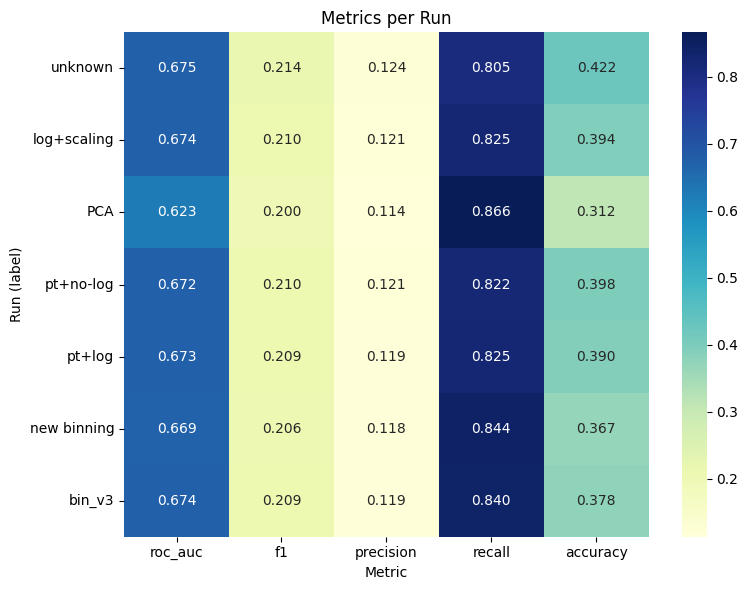

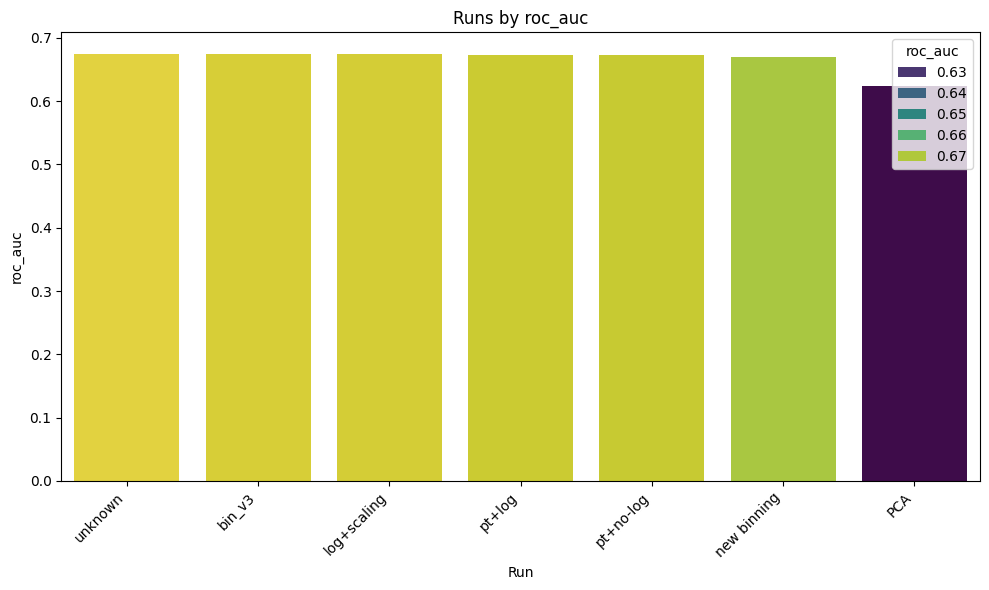

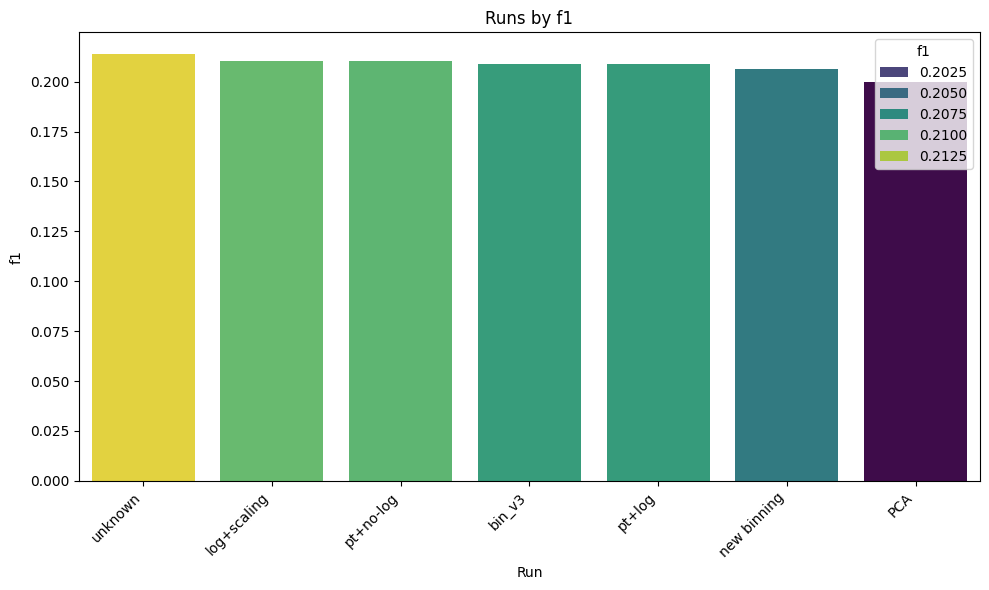

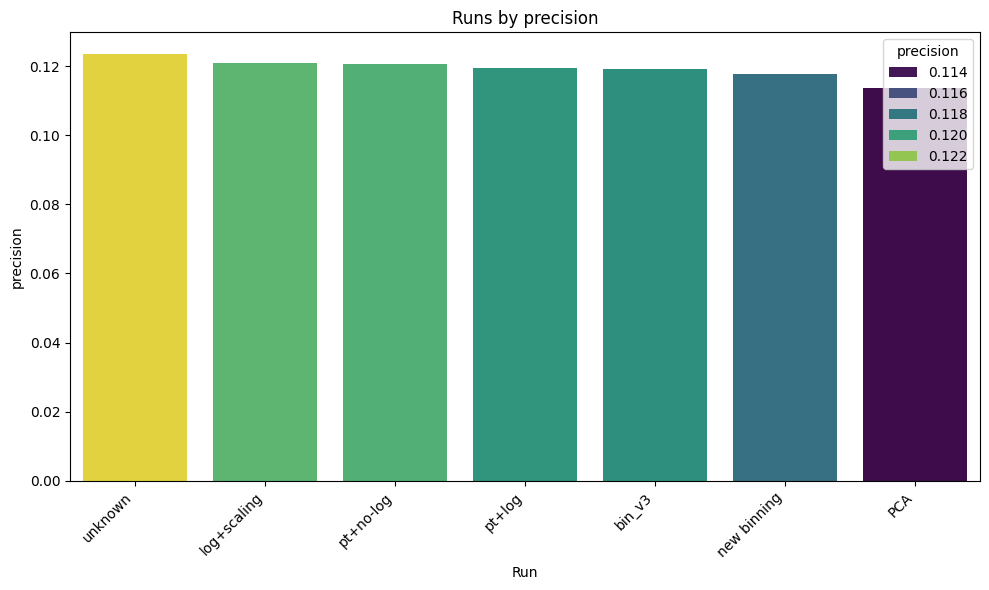

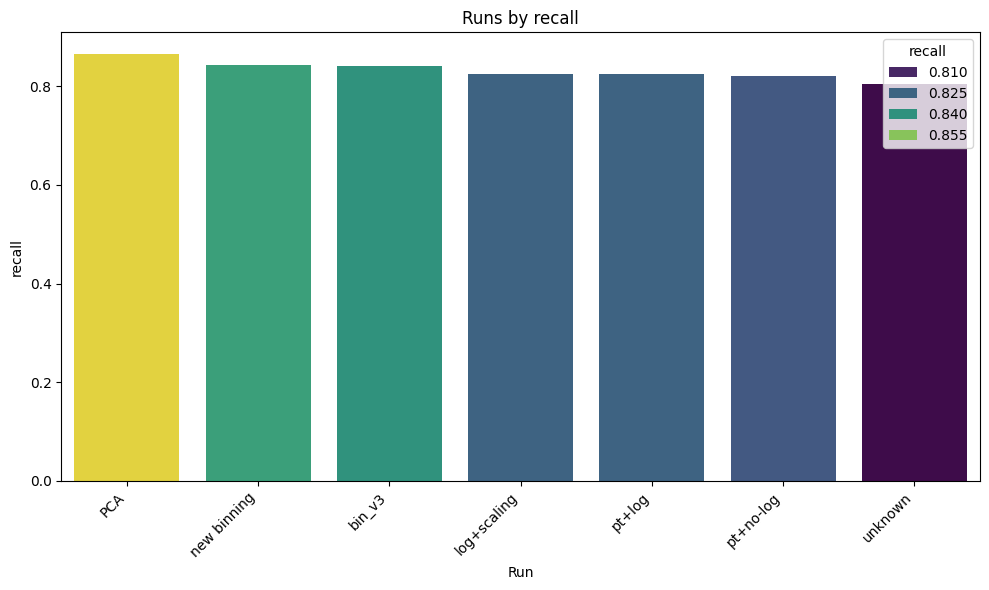

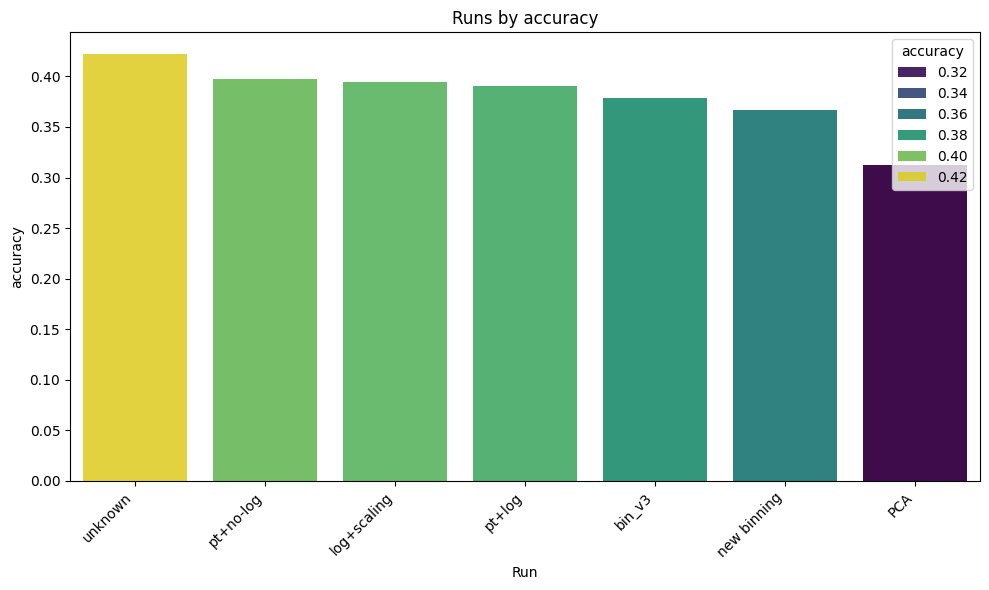

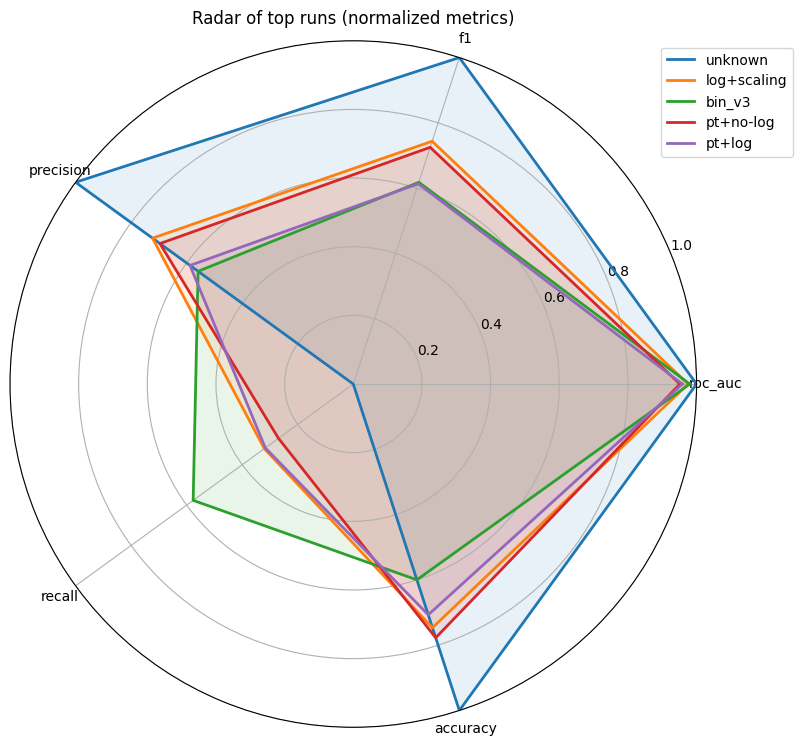

,run_id,label,roc_auc,f1,precision,recall,accuracy,rank_roc_auc,rank_f1,rank_precision,rank_recall,rank_accuracy,rank_sum,overall_score
0,0,unknown,0.674956,0.213998,0.123569,0.805169,0.422439,1.0,1.0,1.0,7.0,1.0,11.0,0.800000
1,1,log+scaling,0.673702,0.210414,0.120832,0.824718,0.394438,3.0,2.0,2.0,4.0,3.0,14.0,0.700000
2,6,bin_v3,0.673936,0.208656,0.119211,0.840356,0.378241,2.0,4.0,5.0,3.0,5.0,19.0,0.533333
3,3,pt+no-log,0.672461,0.210153,0.120568,0.821604,0.397838,5.0,3.0,3.0,6.0,2.0,19.0,0.533333
4,4,pt+log,0.672828,0.208591,0.119499,0.824500,0.390067,4.0,5.0,4.0,5.0,4.0,22.0,0.433333
5,5,new binning,0.669266,0.206300,0.117626,0.843831,0.367092,6.0,6.0,6.0,2.0,6.0,26.0,0.300000
6,2,PCA,0.623478,0.200012,0.113691,0.866203,0.311991,7.0,7.0,7.0,1.0,7.0,29.0,0.200000


In [9]:
from shared_util.metrics.compare_linear import compare_runs

compare_runs(
    df=df_label,
    metric_cols=["roc_auc", "f1", "precision", "recall", "accuracy"]
)

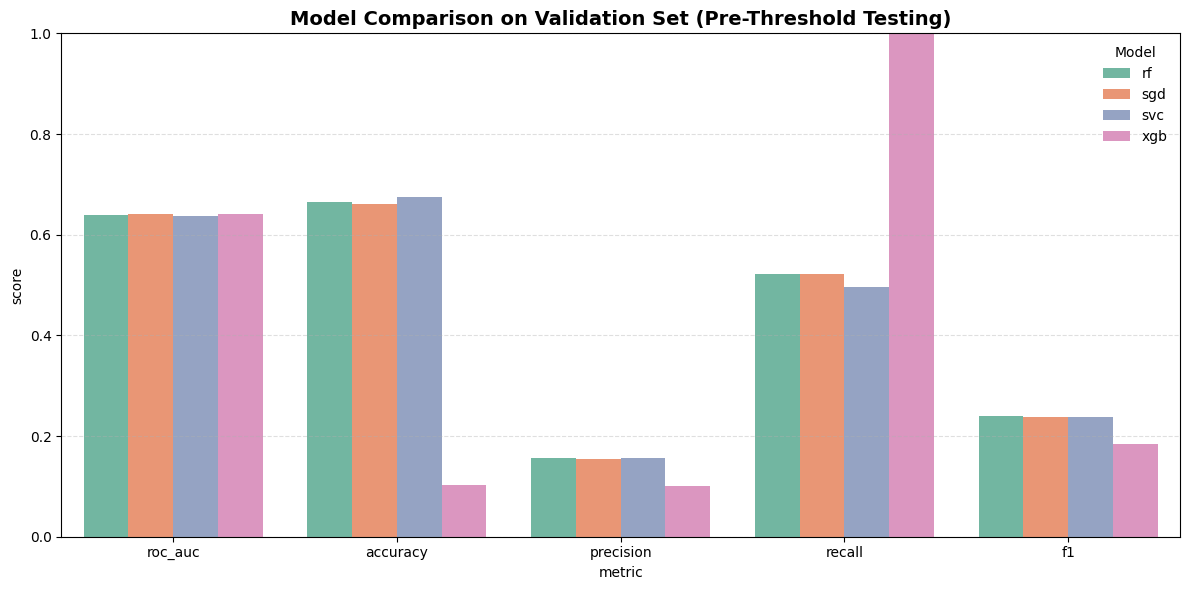

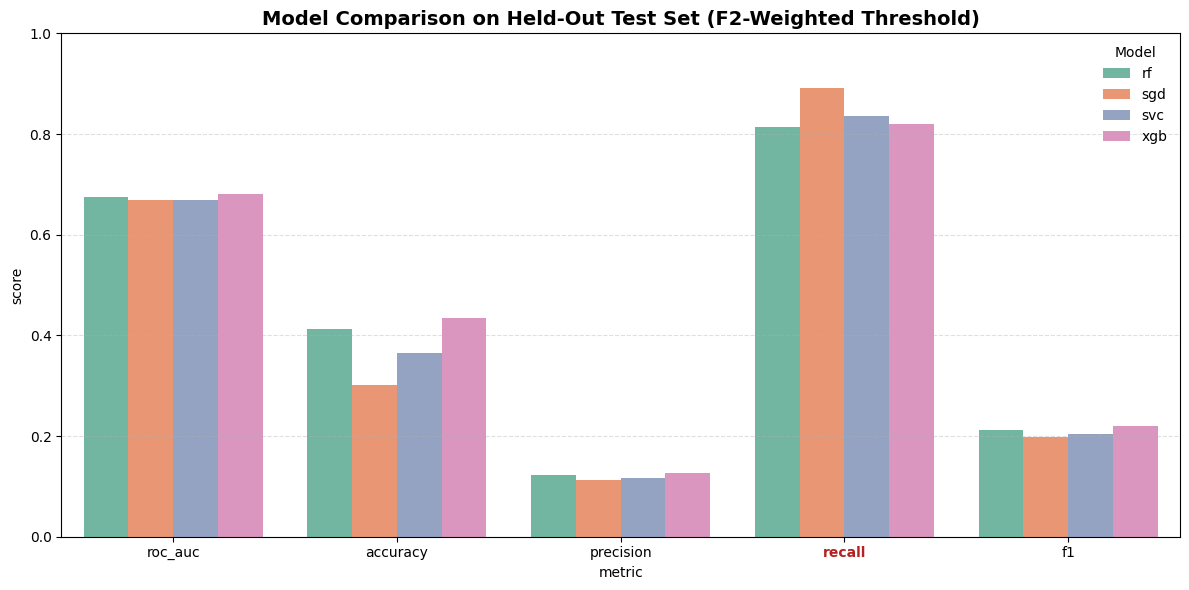

In [4]:
from shared_util.results.results import summary_by_auc, summary_by_recall, plot_metrics

plot_metrics(most_recent_df, METRICS_DB_ID)

In [5]:
print('--most recent--')
summary_by_auc(most_recent_df, plot_id=METRICS_DB_ID)
summary_by_recall(most_recent_df)

# print('--no pca--')
# summary_by_auc(results_df, plot_id=1)
# summary_by_recall(results_df)



--most recent--
Models by ROC_AUC


,model,roc_auc
0,xgb,0.681
1,rf,0.676
2,svc,0.670
3,sgd,0.669


Models by Recall


,model,recall
7,sgd,0.891
4,svc,0.836
0,xgb,0.820
11,rf,0.814


### Hyperparameter Display

In [ ]:
from shared_util.fetch import fetch_params_by_id
import pandas as pd
import ast
import re

h_params_df = fetch_params_by_id(run_id=METRICS_DB_ID)

h_params_df.head(5)


_np_wrapper = re.compile(r"np\.(?:float|int)\d+\(([^)]+)\)")

def parse_hyperparams(text: str) -> pd.DataFrame:
    cleaned = _np_wrapper.sub(r"\1", text)
    params = ast.literal_eval(cleaned)

    def normalize(value):
        if isinstance(value, np.generic):
            return value.item()
        return value

    data = {k: normalize(v) for k, v in params.items()}
    return pd.DataFrame(data.items(), columns=["param", "value"])

for row in h_params_df.itertuples():
    print(f'Model: {row.model}')
    display(parse_hyperparams(row.hyperparam_text)) # type: ignore


Model: xgb


,param,value
0,model__colsample_bytree,5.325258e-01
1,model__gamma,4.744428e+00
2,model__learning_rate,2.900333e-01
3,model__max_depth,3.000000e+00
4,model__min_child_weight,9.000000e+00
5,model__n_estimators,7.640000e+02
6,model__reg_alpha,4.132918e-07
7,model__reg_lambda,5.285382e-02
8,model__scale_pos_weight,1.614304e+01
9,model__subsample,8.049983e-01


Model: svc


,param,value
0,model__C,4.418442
1,model__class_weight,balanced
2,model__gamma,0.001
3,model__kernel,rbf
4,model__shrinking,False


Model: sgd


,param,value
0,model__tol,0.001
1,model__shuffle,True
2,model__penalty,l2
3,model__max_iter,100
4,model__loss,hinge
5,model__learning_rate,adaptive
6,model__l1_ratio,0.5
7,model__eta0,0.0003
8,model__class_weight,None
9,model__average,True


# Random Forest

After reading (Liu, V. et al.) and (Mahmoud, M. et al.) I decided to begin expirementing with random forest models instead of logistic regression models.

In other studies, random forest models were shown to out perform logsitic regression and support vector models likely due to the mix of tabular, categorical, and numerical features

### Define Pipeline

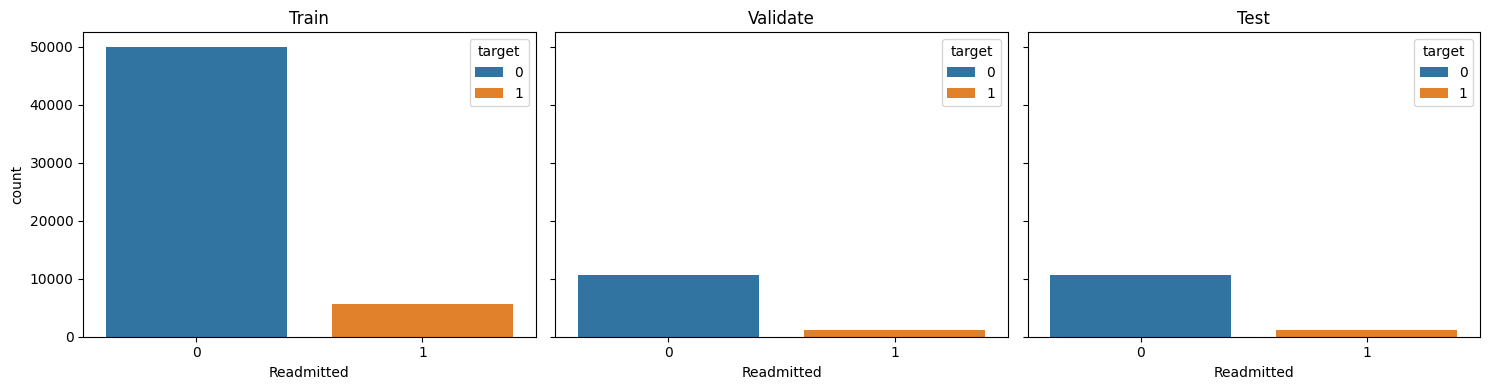

In [2]:

model = 'rf' # Random Forest


model_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,        
    data_path='cleaned',             # csv file name where the data is
    plot_y_dist=True,                # show the target distribution between splits   
    random_state=42,
    log_transform_cols=np.array([]), # no need to transform for tree models
    model=model,
    scaler=None,
    group_by_col='patient_nbr',
    create_interactions=False # no interaction terms for tree models
)

### Baseline

Get a baseline before looking at feature importance or hyperparameter tuning

We can use this baseline to check class imbalance approach methods, as well as to get a sense if this model can learn anything from the engineered features

In [3]:
model_pipe.run_baseline(
    run_smote=True,
    run_undersampler=True,
    show_duration_info=True,
)

--------SMOTE Baseline--------
roc_auc score per fold:  [0.616 0.609 0.617 0.625 0.614]
mean roc_auc score: , 0.616
-----Undersample Baseline-----
roc_auc score per fold:  [0.643 0.63  0.625 0.657 0.624]
mean roc_auc score: , 0.636
Duration: 0 hrs, 0 mins, 18.2 secs


After several iterations of data cleaning tweaks, baseline SMOTE is performing significantly better with mean ROC of ~0.59

However the random under sampler still outperforms with a mean AUC_ROC of ~0.63

SMOTE performed worse than under sampling so we will stick with under sampling going forward

A mean ROC_AUC score of 0.630 implies that the model has learned something from the data so we will continue analysis.

### Feature Importance

- Tree impurity based importance is naturaly skewed to favor continuous features
- Permutation importance is model agnostic, is uneffected by the large class imbalance, and is not effected by the under sampling technique used

,feature,importance_mean,importance_std
63,v_inpatient_group_none,0.042589,0.006409
65,v_inpatient_group_several,0.006384,0.002308
61,v_inpatient_group_few,0.004979,0.001464
58,v_emergency_group_none,0.004243,0.001600
4,number_diagnoses,0.003719,0.002909
3,num_medications,0.002920,0.004439
0,time_in_hospital,0.002609,0.001735
62,v_inpatient_group_frequent,0.002566,0.001309
68,metformin_flag,0.001959,0.001194
9,diag1_group_musculoskeletal,0.001721,0.000245


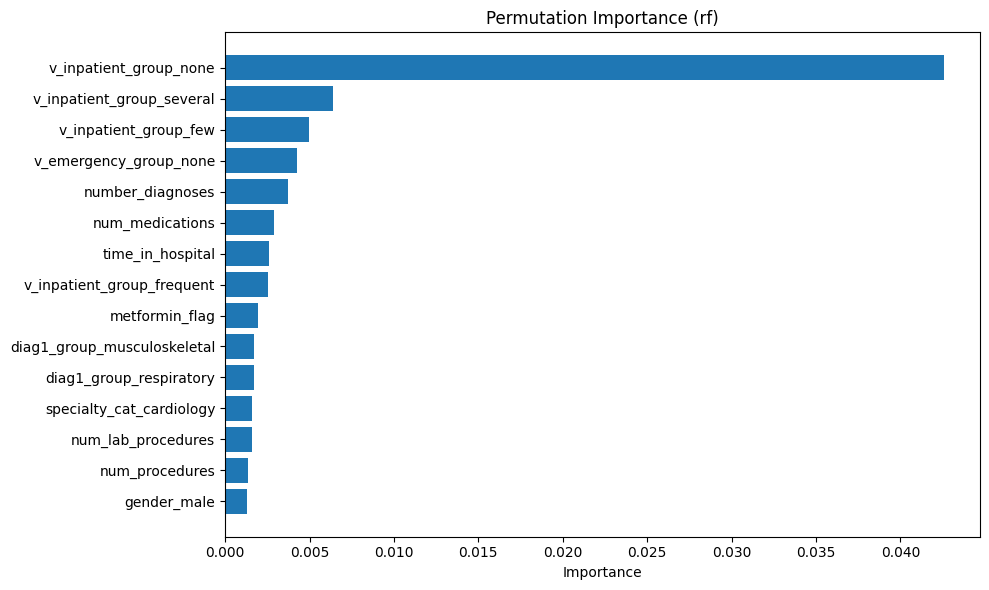

Duration: 0 hrs, 0 mins, 52.1 secs


In [5]:
model_pipe.permute_importance(
    print_num=15,
    plot=True,
    show_duration_info=True
)

In [6]:
param_grid = {
        'model__n_estimators': [100, 200, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10, 15, 20],
        'model__min_samples_leaf': [1, 2, 4, 6, 10],
        'model__max_features': ['sqrt', 'log2', 0.2, 0.5],
        'model__class_weight': [None, 'balanced'],
        'model__bootstrap': [True, False],
        'model__oob_score': [True, False]
    }

model_pipe.run_hyperparam_search(
    hyperparam_dist=param_grid,
    param_scoring='roc_auc',
    n_iter=30,
    n_jobs=-1,
    refit=True,
    show_duration_info=True
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.658894640135475
Best params: {'model__oob_score': False, 'model__n_estimators': 100, 'model__min_samples_split': 15, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__class_weight': None, 'model__bootstrap': True}
logged hyperparameters
Duration: 0 hrs, 0 mins, 34.7 secs


In [7]:
model_pipe.validate(
    show_duration_info=False,
    use_local_model=False
)

# model_pipe.validate(
#     show_duration_info=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

Held out validation metrics: rf
ROC_AUC:     0.6387934767189831
Accuracy:      0.6651819480628625
F1 score:      0.24056423942051086
Precision:     0.15626547795938583
Recall:        0.5223509933774835

Confusion matrix:

TN: 7284, FP: 3407, FN: 577, TP: 631

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.79     10691
           1       0.16      0.52      0.24      1208

    accuracy                           0.67     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.67      0.73     11899



Best threshold (F2): 0.4296
Precision: 0.123  Recall: 0.800  F2: 0.381


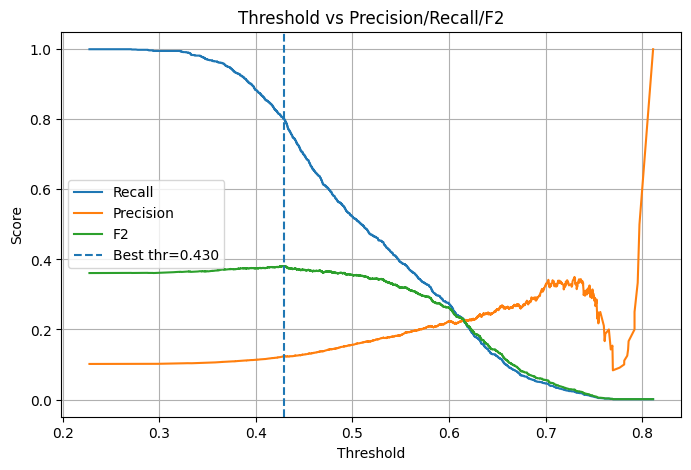

ROC_AUC:     0.6756756767741666
Accuracy:      0.41177464312864265
F1 score:      0.21203892283322018
Precision:     0.12189410693378432
Recall:        0.8140747176368376

Confusion matrix:

TN: 3938, FP: 6750, FN: 214, TP: 937

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.37      0.53     10688
           1       0.12      0.81      0.21      1151

    accuracy                           0.41     11839
   macro avg       0.54      0.59      0.37     11839
weighted avg       0.87      0.41      0.50     11839



In [8]:
model_pipe.test(
    use_f2_threshold=True,
    show_duration_info=False,
    show_plot=True,
    use_local_model=False
)
# model_pipe.test(
#     use_f2_threshold=True,
#     show_duration_info=True,
#     show_plot=True,
#     use_local_model=True,
#     oob_score=True,
#     n_estimators=200,
#     min_samples_split=10,
#     min_samples_leaf=4,
#     max_features=0.2,
#     max_depth=10,
#     class_weight='balanced',
#     bootstrap=True
# )

# Stochastic Gradient Descent Classifier

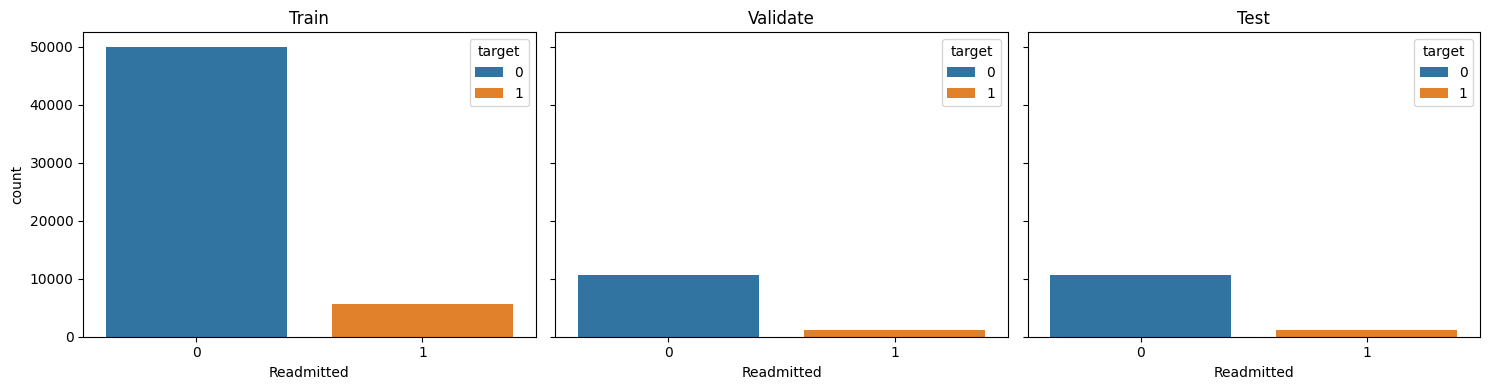

In [9]:
model = 'sgd' #SGDClassifier


sgd_pipe = ModelPipeline(
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    model=model,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True
)



,feature,importance_mean,importance_std
63,v_inpatient_group_none,0.023421,0.003956
65,v_inpatient_group_several,0.011599,0.001201
0,time_in_hospital,0.010392,0.005723
61,v_inpatient_group_few,0.006732,0.003174
62,v_inpatient_group_frequent,0.005988,0.003705
9,diag1_group_musculoskeletal,0.005226,0.001476
58,v_emergency_group_none,0.003600,0.001796
4,number_diagnoses,0.003272,0.002249
69,insulin_flag,0.001652,0.001800
3,num_medications,0.001490,0.002811


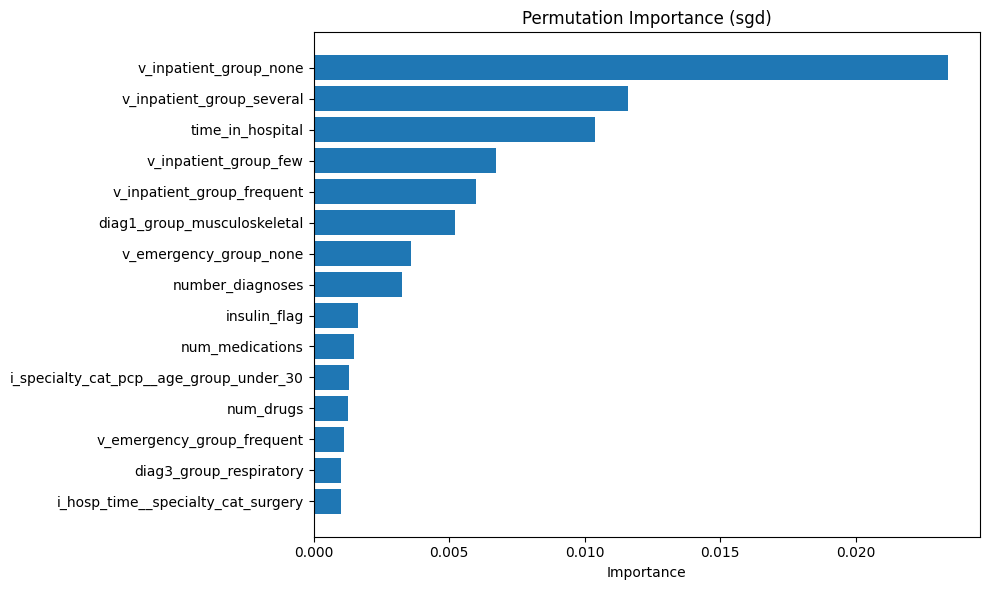

Duration: 0 hrs, 0 mins, 15.4 secs


In [10]:
if not PCA:
    sgd_pipe.permute_importance()

In [11]:
sgd_pipe.run_baseline() # all true

--------SMOTE Baseline--------
roc_auc score per fold:  [0.535 0.558 0.521 0.536 0.521]
mean roc_auc score: , 0.534
-----Undersample Baseline-----
roc_auc score per fold:  [0.599 0.57  0.579 0.6   0.619]
mean roc_auc score: , 0.593
Duration: 0 hrs, 0 mins, 12.6 secs


In [12]:
sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

sgd_pipe.run_hyperparam_search(hyperparam_dist=sgd_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6582234942339868
Best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}
logged hyperparameters
Duration: 0 hrs, 0 mins, 43.2 secs


In [13]:
sgd_pipe.validate(show_duration_info=False)

Held out validation metrics: sgd
ROC_AUC:     0.641088840585725
Accuracy:      0.6618203210353811
F1 score:      0.2384557153671461
Precision:     0.15456329735034346
Recall:        0.5215231788079471

Confusion matrix:

TN: 7245, FP: 3446, FN: 578, TP: 630

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.68      0.78     10691
           1       0.15      0.52      0.24      1208

    accuracy                           0.66     11899
   macro avg       0.54      0.60      0.51     11899
weighted avg       0.85      0.66      0.73     11899



Best threshold (F2): 0.3719
Precision: 0.116  Recall: 0.894  F2: 0.382


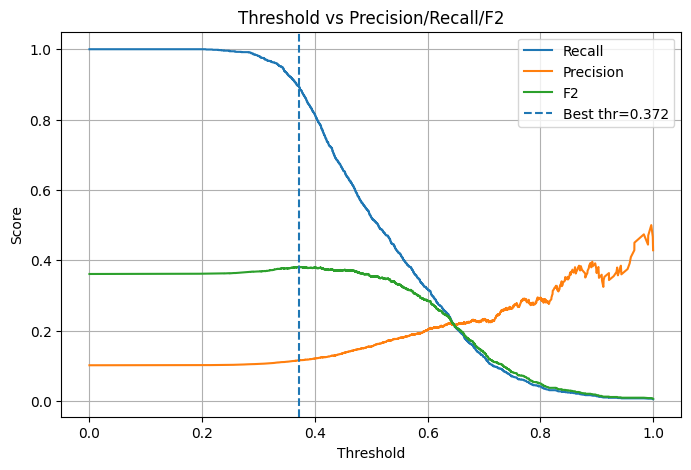

ROC_AUC:     0.669253126024233
Accuracy:      0.30205253822113354
F1 score:      0.19893359185651963
Precision:     0.11195984286337844
Recall:        0.891398783666377

Confusion matrix:

TN: 2550, FP: 8138, FN: 125, TP: 1026

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.24      0.38     10688
           1       0.11      0.89      0.20      1151

    accuracy                           0.30     11839
   macro avg       0.53      0.56      0.29     11839
weighted avg       0.87      0.30      0.36     11839



In [14]:
sgd_pipe.test(show_duration_info=False)

# Support Vector Classifier

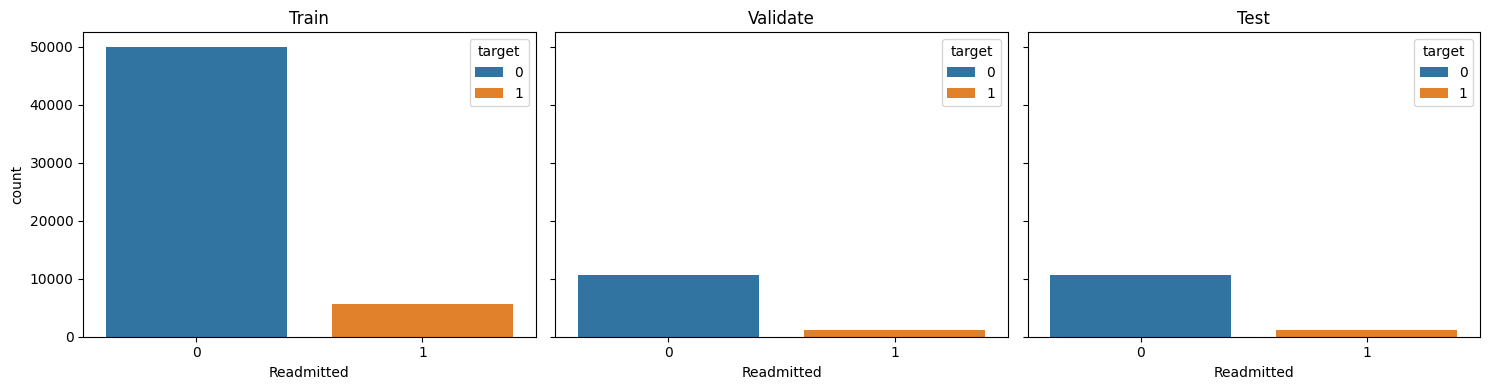

In [15]:

svc_pipe = ModelPipeline(
    model='svc',
    log=UPDATE_DATABASE,
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log_transform_cols=LOG_TRANSFORM_COLS,
    scaler=scaler,
    use_pca=PCA,
    create_interactions=True
)

In [16]:
svc_pipe.run_baseline(run_smote=False) # smote did not complete after ~6 hours

-----Undersample Baseline-----
roc_auc score per fold:  [0.647 0.634 0.641 0.661 0.635]
mean roc_auc score: , 0.644
Duration: 0 hrs, 0 mins, 15.9 secs


In [17]:
# slow
# svc_pipe.permute_importance()

In [18]:
from scipy.stats import loguniform


# limited param search due to computation time
svc_param_grid = {
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],     
}

svc_pipe.run_hyperparam_search(hyperparam_dist=svc_param_grid)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6551043273080353
Best params: {'model__C': np.float64(0.1767016940294795), 'model__gamma': 0.001}
logged hyperparameters
Duration: 0 hrs, 12 mins, 4.5 secs


In [19]:
svc_pipe.validate()

Held out validation metrics: svc
ROC_AUC:     0.6370480276471947
Accuracy:      0.6754349104966804
F1 score:      0.2370604504148558
Precision:     0.15568240788790866
Recall:        0.4966887417218543

Confusion matrix:

TN: 7437, FP: 3254, FN: 608, TP: 600

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.70      0.79     10691
           1       0.16      0.50      0.24      1208

    accuracy                           0.68     11899
   macro avg       0.54      0.60      0.52     11899
weighted avg       0.85      0.68      0.74     11899



Best threshold (F2): -0.7720
Precision: 0.120  Recall: 0.841  F2: 0.381


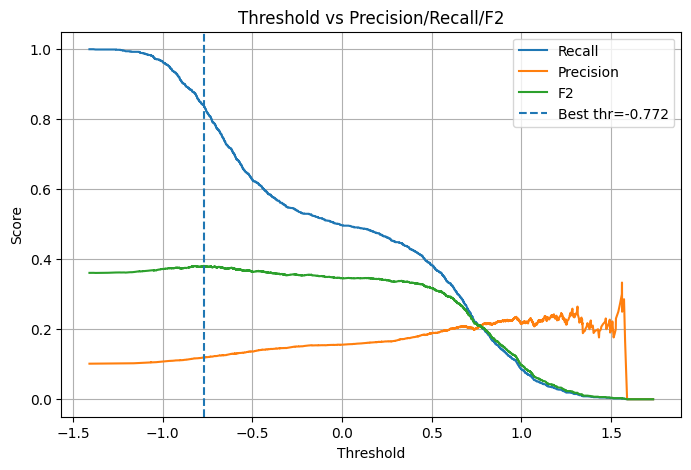

ROC_AUC:     0.6698392555679258
Accuracy:      0.3647267505701495
F1 score:      0.20370566437268395
Precision:     0.11598746081504702
Recall:        0.8357949609035621

Confusion matrix:

TN: 3356, FP: 7332, FN: 189, TP: 962

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.31      0.47     10688
           1       0.12      0.84      0.20      1151

    accuracy                           0.36     11839
   macro avg       0.53      0.57      0.34     11839
weighted avg       0.87      0.36      0.45     11839



In [20]:
svc_pipe.test()

# XGBoost

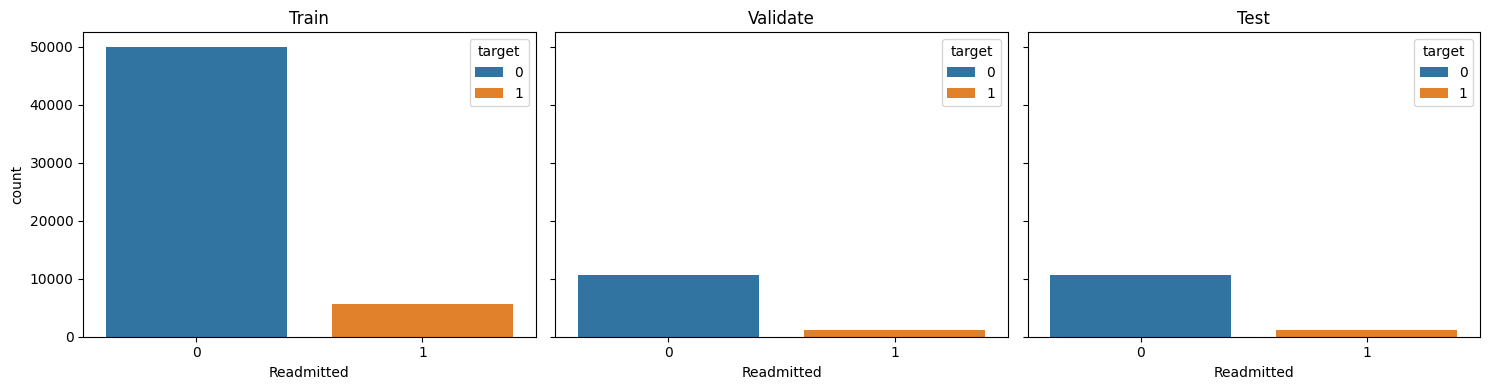

In [21]:
xgb_pipe = ModelPipeline(
    model='xgb',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRICS_NOTES,
    log=UPDATE_DATABASE,
    create_interactions=False,
    log_transform_cols=LOG_TRANSFORM_COLS,
    use_pca=PCA,
    scaler=None
)

In [22]:
xgb_pipe.run_baseline()

--------SMOTE Baseline--------
roc_auc score per fold:  [0.607 0.624 0.603 0.61  0.606]
mean roc_auc score: , 0.610
-----Undersample Baseline-----
roc_auc score per fold:  [0.624 0.624 0.612 0.631 0.618]
mean roc_auc score: , 0.622
Duration: 0 hrs, 0 mins, 12.0 secs


,feature,importance_mean,importance_std
63,v_inpatient_group_none,0.066602,0.010227
3,num_medications,0.009139,0.002797
1,num_lab_procedures,0.007747,0.003713
0,time_in_hospital,0.005479,0.001422
2,num_procedures,0.004846,0.000879
4,number_diagnoses,0.004739,0.002290
70,num_drugs,0.003502,0.000553
9,diag1_group_musculoskeletal,0.002787,0.000757
34,specialty_cat_cardiology,0.002777,0.001188
58,v_emergency_group_none,0.002505,0.001300


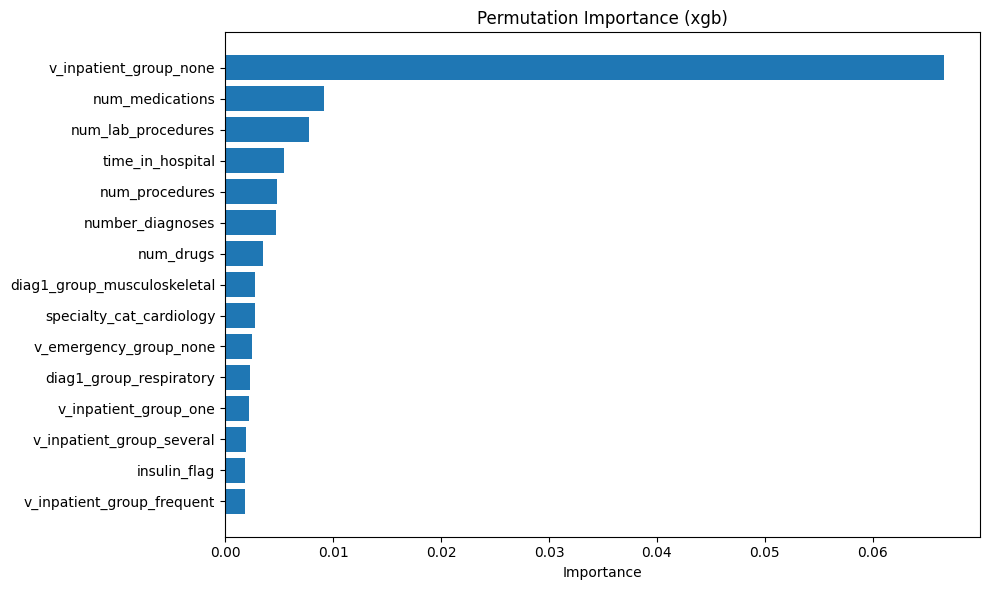

Duration: 0 hrs, 0 mins, 18.9 secs


In [23]:
if not PCA:
    xgb_pipe.permute_importance()

In [24]:
from scipy.stats import randint, uniform, loguniform

approx_spw = float(8.9494) # from data exploration aprox inverse of class balance


param_dist = {
    'model__n_estimators': randint(1000, 2500),
    'model__learning_rate': uniform(0.01, 0.10),
    'model__max_depth': randint(4, 15),
    'model__min_child_weight': randint(1, 8),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': [approx_spw],
}

xgb_pipe.run_hyperparam_search(
    hyperparam_dist=param_dist
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC_AUC (cv): 0.6555286974192381
Best params: {'model__colsample_bytree': np.float64(0.587477463547968), 'model__gamma': np.float64(4.910841716647178), 'model__learning_rate': np.float64(0.06166358912710143), 'model__max_depth': 4, 'model__min_child_weight': 2, 'model__n_estimators': 1896, 'model__reg_alpha': np.float64(4.4845552058286884e-08), 'model__reg_lambda': np.float64(4.916400722913763), 'model__scale_pos_weight': 8.9494, 'model__subsample': np.float64(0.9502090285816652)}
logged hyperparameters
Duration: 0 hrs, 7 mins, 31.6 secs


In [25]:
xgb_pipe.validate()

Held out validation metrics: xgb
ROC_AUC:     0.640933126892026
Accuracy:      0.10345407177073704
F1 score:      0.18465301131152553
Precision:     0.10171775008420343
Recall:        1.0

Confusion matrix:

TN: 23, FP: 10668, FN: 0, TP: 1208

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.00      0.00     10691
           1       0.10      1.00      0.18      1208

    accuracy                           0.10     11899
   macro avg       0.55      0.50      0.09     11899
weighted avg       0.91      0.10      0.02     11899



Best threshold (F2): 0.8596
Precision: 0.125  Recall: 0.786  F2: 0.382


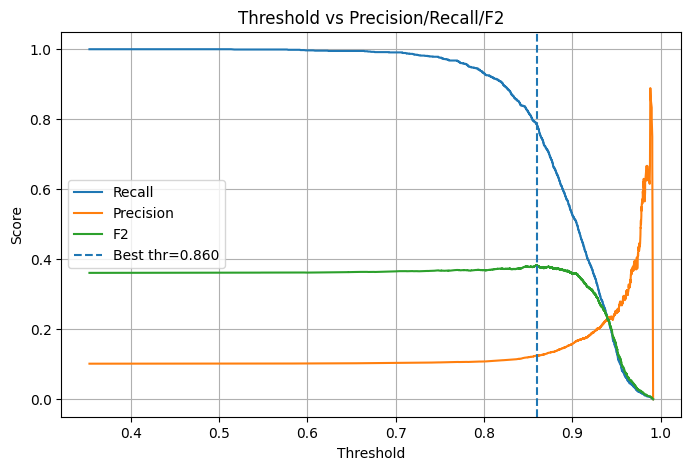

ROC_AUC:     0.6809766923581162
Accuracy:      0.4344116901765352
F1 score:      0.21994408201304752
Precision:     0.12700121081662855
Recall:        0.8201563857515204

Confusion matrix:

TN: 4199, FP: 6489, FN: 207, TP: 944

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.39      0.56     10688
           1       0.13      0.82      0.22      1151

    accuracy                           0.43     11839
   macro avg       0.54      0.61      0.39     11839
weighted avg       0.87      0.43      0.52     11839



In [26]:
xgb_pipe.test()

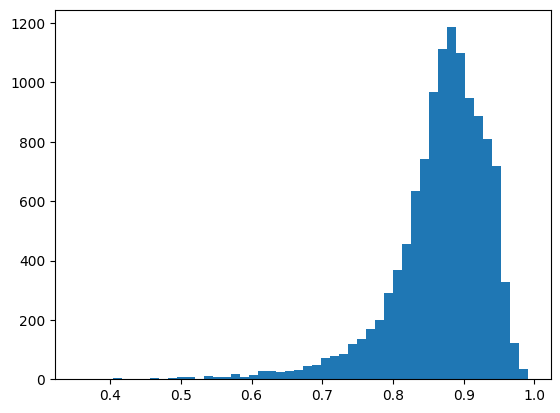

In [27]:
import matplotlib.pyplot as plt
from shared_util.dataio import load_csv



df = load_csv('cleaned')
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)
plt.hist(xgb_pipe.randomized_search.best_estimator_.predict_proba(X_validate)[:,1], bins=50) #type: ignore
plt.show()
